[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1AchN-_R6ZLQmKgMV8Dmxrncx7a5dXGKF?usp=sharing)


This was mostly run on google colab except for a block that needs more memory. The coded is a bit bloated since it's mostly written by ChatGPT. Also, there's a few patches awkwardly added in at the end.

In [ ]:
!pip -q install hdbscan scikit-learn pandas numpy matplotlib

In [ ]:
!pip -q install shapely scipy

In [ ]:
import json
import math
from pathlib import Path
import os, json, math, hashlib

from shapely.geometry import shape, Polygon, MultiPolygon, mapping
from shapely.ops import transform
from shapely.strtree import STRtree
from scipy.spatial import Voronoi
from shapely.geometry import Polygon, box
from shapely.ops import unary_union, transform
import numpy as np
from sklearn.neighbors import NearestNeighbors


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import hdbscan

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
!wget https://github.com/leonfrench/polyprotein_stats/raw/refs/heads/cca_100_3x/data/processed/GCCA_shared_embedding.center_and_normalize_False.dim_100.UMAP.csv

--2026-01-22 01:27:39--  https://github.com/leonfrench/polyprotein_stats/raw/refs/heads/cca_100_3x/data/processed/GCCA_shared_embedding.center_and_normalize_False.dim_100.UMAP.csv
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/leonfrench/polyprotein_stats/refs/heads/cca_100_3x/data/processed/GCCA_shared_embedding.center_and_normalize_False.dim_100.UMAP.csv [following]
--2026-01-22 01:27:39--  https://raw.githubusercontent.com/leonfrench/polyprotein_stats/refs/heads/cca_100_3x/data/processed/GCCA_shared_embedding.center_and_normalize_False.dim_100.UMAP.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK

In [ ]:

csv_path = "GCCA_shared_embedding.center_and_normalize_False.dim_100.UMAP.csv"
df = pd.read_csv(csv_path)

coord_cols = ["UMAP 0", "UMAP 1"]

# ensure they exist and are numeric (coerce if needed)
missing = [c for c in coord_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Available columns: {df.columns.tolist()[:20]} ...")

df[coord_cols] = df[coord_cols].apply(pd.to_numeric, errors="coerce")
if df[coord_cols].isna().any().any():
    bad = df[df[coord_cols].isna().any(axis=1)].head(5)
    raise ValueError(f"Found non-numeric values in UMAP columns after coercion. Example rows:\n{bad}")

# --- NEW: scale coords to Lon/Lat with a 10% total buffer (5% each side), then de-collide close points ---

LON_MIN, LON_MAX = -180.0, 180.0
LAT_MIN, LAT_MAX = -85.05112878, 85.05112878  # Web Mercator max latitude
BUFFER_FRAC = 0.10  # take away 10% of total span for buffer

lon_buf = (LON_MAX - LON_MIN) * BUFFER_FRAC / 2.0
lat_buf = (LAT_MAX - LAT_MIN) * BUFFER_FRAC / 2.0

LON_MIN_IN, LON_MAX_IN = LON_MIN + lon_buf, LON_MAX - lon_buf
LAT_MIN_IN, LAT_MAX_IN = LAT_MIN + lat_buf, LAT_MAX - lat_buf

raw = df[coord_cols].to_numpy(dtype=np.float64)
x = raw[:, 0]
y = raw[:, 1]

def rescale_1d(a, new_min, new_max):
    a_min = a.min()
    a_max = a.max()
    if a_max == a_min:
        return np.full_like(a, (new_min + new_max) / 2.0, dtype=np.float64)
    return (a - a_min) / (a_max - a_min) * (new_max - new_min) + new_min

x = rescale_1d(x, LON_MIN_IN, LON_MAX_IN)
y = rescale_1d(y, LAT_MIN_IN, LAT_MAX_IN)

coords = np.column_stack([x, y]).astype(np.float32)

# jitter only points whose nearest-neighbor is "too close"
MIN_SEP_FRAC = 4e-5    # fraction of map diagonal; points closer than this get jittered
JITTER_SEED = 1

nn = NearestNeighbors(n_neighbors=2).fit(coords)  # 0th neighbor is itself
dists, _ = nn.kneighbors(coords)
nn_dist = dists[:, 1]

diag = np.linalg.norm(coords.max(axis=0) - coords.min(axis=0))
min_sep = MIN_SEP_FRAC * (diag if diag > 0 else 1.0)

too_close = nn_dist < min_sep
if np.any(too_close):
    rng = np.random.default_rng()
    angles = rng.uniform(0, 2*np.pi, too_close.sum())

    # base push
    base_mag = (min_sep - nn_dist[too_close]) * 0.6 + min_sep * 25

    # add randomness: multiplicative jitter around 1.0 (e.g., 0.7x to 1.3x)
    rand_mult = rng.uniform(0.7, 1.3, too_close.sum())
    mag = base_mag * rand_mult

    coords[too_close] += np.c_[np.cos(angles), np.sin(angles)] * mag[:, None]

    # keep everything inside the buffered Lon/Lat bounds
    coords[:, 0] = np.clip(coords[:, 0], LON_MIN_IN, LON_MAX_IN)
    coords[:, 1] = np.clip(coords[:, 1], LAT_MIN_IN, LAT_MAX_IN)

    print(f"Jittered {too_close.sum()} / {len(coords)} points (min_sep={min_sep:.4g})")

# write back so downstream code + CSV export uses the updated coords
df.loc[:, coord_cols] = coords
X = coords


Jittered 913 / 17890 points (min_sep=0.01433)


In [ ]:
min_cluster_size = 8   # main knob; smaller -> more clusters
min_samples = 5       # higher -> more conservative (more noise)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    cluster_selection_method="eom"  # or "leaf" for more (smaller) clusters
)

labels = clusterer.fit_predict(X)  # -1 is noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_frac = np.mean(labels == -1)

print("clusters:", n_clusters, "noise_frac:", noise_frac)
df["hdbscan_cluster"] = labels

clusters: 458 noise_frac: 0.284460592509782


In [ ]:
#If you want every point assigned, simplest approach: assign each noise point to the nearest non-noise point’s cluster.
from sklearn.neighbors import NearestNeighbors

lab = df["hdbscan_cluster"].to_numpy()
good = lab != -1
if good.sum() == 0:
    raise ValueError("HDBSCAN found no clusters; decrease min_samples/min_cluster_size.")

nn = NearestNeighbors(n_neighbors=1).fit(X[good])
dist, idx = nn.kneighbors(X[~good])
filled = lab.copy()
filled[~good] = lab[good][idx[:,0]]

df["hdbscan_filled_cluster"] = filled
print("filled clusters:", len(np.unique(filled)))


filled clusters: 458


In [ ]:
df

,Unnamed: 0,gene_symbol,UMAP 0,UMAP 1,hdbscan_cluster,hdbscan_filled_cluster
0,0,A1BG,16.121214,33.326889,-1,223
1,1,A1CF,-20.499163,11.073771,-1,264
2,2,A2M,50.520176,-13.308219,182,182
3,3,A2ML1,50.449684,-13.326718,182,182
4,4,A3GALT2,74.248741,-4.674804,205,205
...,...,...,...,...,...,...
17885,17885,ZXDC,-30.756424,10.687180,144,144
17886,17886,ZYG11A,88.447113,19.014849,-1,86
17887,17887,ZYG11B,87.906174,18.793901,-1,86
17888,17888,ZYX,12.969931,9.443592,379,379


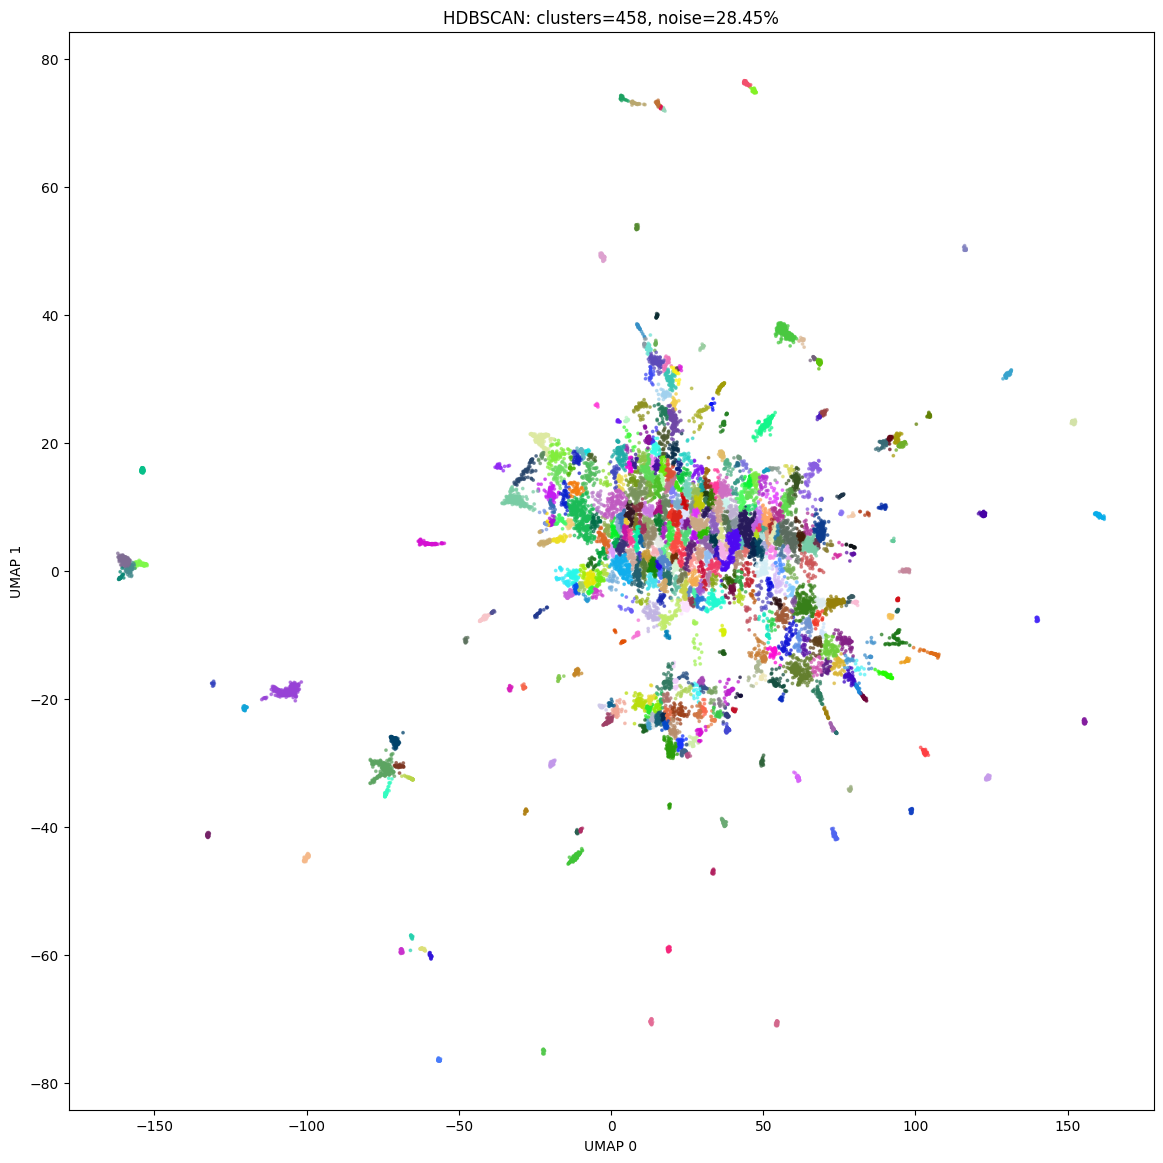

In [ ]:
import numpy as np

labels = df["hdbscan_filled_cluster"].to_numpy()
uniq = np.unique(labels)

rng = np.random.default_rng(1)  # change seed for different random colors
color_map = {lab: rng.random(3) for lab in uniq}  # RGB in [0,1]
colors = np.array([color_map[lab] for lab in labels])

plt.figure(figsize=(14,14))
plt.scatter(df['UMAP 0'], df['UMAP 1'], s=3, c=colors, alpha=0.6)
plt.title(f"HDBSCAN: clusters={n_clusters}, noise={noise_frac:.2%}")
plt.xlabel(coord_cols[0]); plt.ylabel(coord_cols[1])
plt.show()


In [ ]:

labels = df["hdbscan_filled_cluster"].to_numpy()

# sizes per cluster
uniq, counts = np.unique(labels, return_counts=True)

print("n_clusters:", len(uniq))
print("min size:", int(counts.min()))
print("median size:", float(np.median(counts)))
print("max size:", int(counts.max()))


n_clusters: 458
min size: 8
median size: 28.5
max size: 275


In [ ]:
df = df[["gene_symbol", "UMAP 0", "UMAP 1", "hdbscan_filled_cluster"]]

In [ ]:
df

,gene_symbol,UMAP 0,UMAP 1,hdbscan_filled_cluster
0,A1BG,16.121214,33.326889,223
1,A1CF,-20.499163,11.073771,264
2,A2M,50.520176,-13.308219,182
3,A2ML1,50.449684,-13.326718,182
4,A3GALT2,74.248741,-4.674804,205
...,...,...,...,...
17885,ZXDC,-30.756424,10.687180,144
17886,ZYG11A,88.447113,19.014849,86
17887,ZYG11B,87.906174,18.793901,86
17888,ZYX,12.969931,9.443592,379


In [ ]:
#df.to_csv("HBSCAN_clusters.csv")

In [ ]:
df = pd.read_csv("HBSCAN_clusters.csv", index_col=0)

In [ ]:
#!pip install pandas shapely geopandas
#RAN ON a high memory machine
#code for numpy loading trouble:
#import sys
#!{sys.executable} -m pip install --upgrade --ignore-installed --no-cache-dir numpy
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.ops import voronoi_diagram, unary_union
from shapely.geometry import MultiPoint, Point, Polygon, MultiPolygon

def generate_perfect_single_borders(df, x_col='UMAP 0', y_col='UMAP 1',
                                    cluster_col='hdbscan_filled_cluster',
                                    max_dist=0.3, smoothing=0.1):
    # 1. Convert to GeoPandas
    gdf = gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df[x_col], df[y_col]), crs=None
    ).reset_index(drop=True)

    # 2. Compute Voronoi Territories (The "Hard" boundaries)
    all_points = MultiPoint(gdf.geometry.tolist())
    # Expand envelope slightly to ensure coverage
    env = all_points.envelope.buffer(max_dist * 10)
    voronoi_cells = voronoi_diagram(all_points, envelope=env)

    vor_gdf = gpd.GeoDataFrame(geometry=list(voronoi_cells.geoms), crs=None)
    vor_with_ids = gpd.sjoin(vor_gdf, gdf[[cluster_col, 'geometry']], how="inner", predicate="contains")

    # Dissolve to get one territory per cluster
    territories = vor_with_ids.dissolve(by=cluster_col)

    # 3. Generate smoothed cluster shapes
    final_regions_list = []

    for cluster_id, group in gdf.groupby(cluster_col):
        # Create a "blob" by buffering the points
        points_geom = group.geometry.union_all()

        # BRIDGE: Use buffer-then-unbuffer to bridge multiparts naturally
        # This is safer than convex_hull because it follows the point density
        bridged = points_geom.buffer(max_dist).buffer(-max_dist * 0.8)

        # SMOOTH: Apply smoothing
        smoothed = bridged.buffer(smoothing, join_style=1).buffer(-smoothing, join_style=1)

        # CLIP: Ensure it stays within its Voronoi territory
        if cluster_id in territories.index:
            max_territory = territories.loc[cluster_id].geometry
            final_geom = smoothed.intersection(max_territory)

            # Ensure we only keep the valid polygons
            if not final_geom.is_empty:
                # If bridging failed to make it one piece, you can use convex_hull
                # HERE, but only inside the clipped territory
                if isinstance(final_geom, MultiPolygon):
                    final_geom = final_geom.convex_hull.intersection(max_territory)

                final_regions_list.append({
                    'cluster_id': cluster_id,
                    'geometry': final_geom
                })

    # 4. FINAL STEP: Global Overlap Removal
    # Even with Voronoi clipping, smoothing artifacts can cause tiny overlaps.
    # We iterate and subtract previously processed geometries.
    temp_gdf = gpd.GeoDataFrame(final_regions_list, crs=None)
    cleaned_geoms = []

    # We use a union of everything processed so far to "cut" the next piece
    processed_union = None

    for idx, row in temp_gdf.iterrows():
        geom = row.geometry
        if processed_union is not None:
            # Subtract any part of this geometry that overlaps with previous ones
            geom = geom.difference(processed_union)

        cleaned_geoms.append({
            'cluster_id': row['cluster_id'],
            'geometry': geom
        })

        # Update the union
        if processed_union is None:
            processed_union = geom
        else:
            processed_union = unary_union([processed_union, geom])

    # 5. Export
    borders_gdf = gpd.GeoDataFrame(cleaned_geoms, crs=None)
    # Simplify slightly to remove tiny artifact vertices
    borders_gdf['geometry'] = borders_gdf['geometry'].simplify(0.001)

    borders_gdf.to_file("borders_fixed.geojson", driver='GeoJSON')
    return borders_gdf

# --- Execution ---
# borders = generate_perfect_single_borders(df)

# --- Execution ---


In [ ]:
# RAN ON FIR --- Usage ---
df = pd.read_csv("HBSCAN_clusters.csv", index_col=0)
#generate_island_borders(df, max_dist=0.2, smoothing=0.1)
cluster_polys = generate_perfect_single_borders(df, max_dist=3, smoothing=0)
#cluster_polys = generate_island_borders(df, max_dist=1, smoothing=0.00005)

NameError: name 'generate_single_region_borders' is not defined

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point

def plot_islands_from_file(df, geojson_path, x_col='UMAP 0', y_col='UMAP 1',
                           cluster_col='hdbscan_filled_cluster', figsize=(22, 22), seed=42):
    # 1. Load the borders from the saved file
    try:
        borders_gdf = gpd.read_file(geojson_path)
        print(f"Loaded {len(borders_gdf)} regions from {geojson_path}")
    except Exception as e:
        print(f"Error loading file: {e}")
        return

    rng = np.random.default_rng(seed)
    fig, ax = plt.subplots(figsize=figsize)

    # Setup appearance
    ax.set_facecolor('#ffffff')
    ax.set_aspect("equal", "box")

    # --- NEW: find points not covered by any border ---
    points_gdf = gpd.GeoDataFrame(
        df[[x_col, y_col]].copy(),
        geometry=gpd.points_from_xy(df[x_col], df[y_col]),
        crs=borders_gdf.crs
    )

    borders_poly = borders_gdf[borders_gdf.geometry.notna()].copy()
    sj = gpd.sjoin(points_gdf[["geometry"]], borders_poly[["geometry"]], how="left", predicate="intersects")
    not_covered = sj["index_right"].isna().to_numpy()
    n_missing = int(not_covered.sum())
    print(f"NOT covered by any border: {n_missing} / {len(df)}")

    # 2. Plot the Points (Background)
    ax.scatter(df[x_col], df[y_col], c='lightgray', s=1, alpha=0.3, zorder=1, label='Points')

    # 3. Setup Colors
    cluster_ids = borders_gdf['cluster_id'].unique()
    colors = {cid: rng.random(3) for cid in cluster_ids}

    # 4. Plot Polygons (Middle Layer)
    for _, row in borders_gdf.iterrows():
        cid = row['cluster_id']
        geom = row['geometry']

        if geom is None or geom.is_empty:
            continue

        color = colors[cid]

        # Handle Polygon or MultiPolygon
        polys = [geom] if isinstance(geom, Polygon) else list(geom.geoms)

        for poly in polys:
            x, y = poly.exterior.coords.xy
            patch = MplPolygon(np.c_[x, y], closed=True,
                               facecolor=color,
                               edgecolor=color,
                               linewidth=2,
                               alpha=0.4,
                               zorder=2)
            ax.add_patch(patch)

    # --- NEW: plot uncovered points on top ---
    if n_missing:
        ax.scatter(df.loc[not_covered, x_col], df.loc[not_covered, y_col],
                   c='red', s=6, alpha=0.9, zorder=4, label='Not in any border')

    # Final touches
    ax.autoscale_view()
    ax.set_title(f"Cluster Regions (n={len(cluster_ids)}) | Missing={n_missing}", fontsize=16)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    plt.grid(True, linestyle=':', alpha=0.3)
    ax.legend(loc="upper right")

    plt.show()


Loaded 458 regions from borders.geojson
NOT covered by any border: 0 / 17890


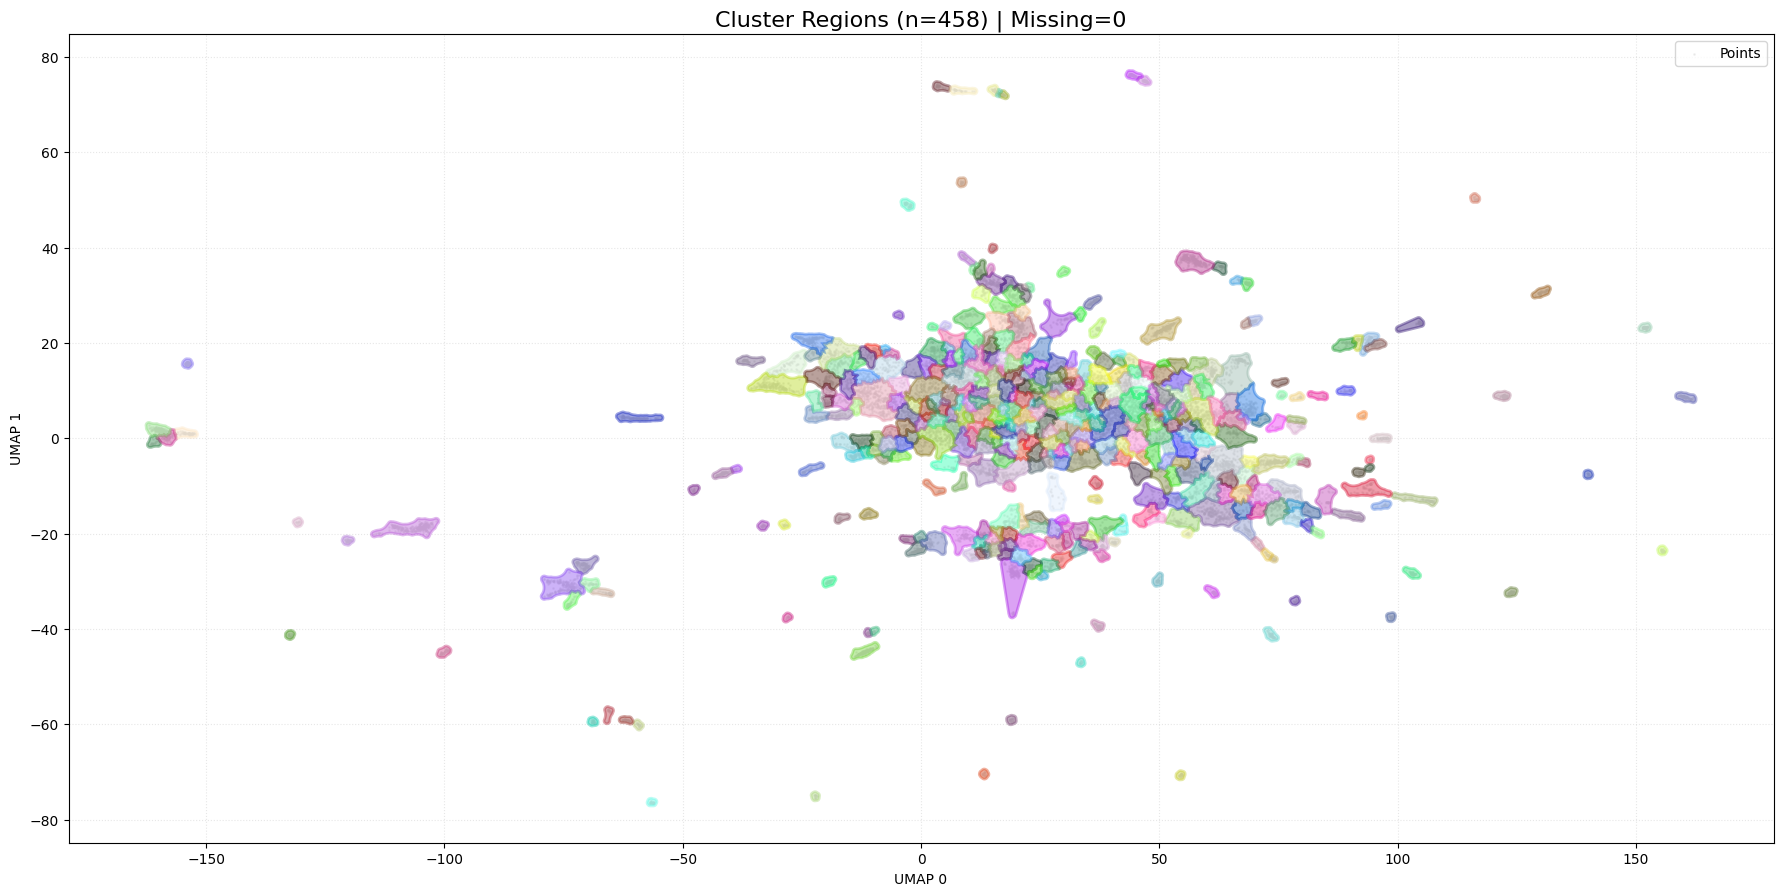

In [ ]:
plot_islands_from_file(df, 'borders.geojson')

In [ ]:
#CHECK code
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

CSV_IN     = "HBSCAN_clusters.csv"
BORDERS_IN = "borders.geojson"

# --- load inputs ---
df = pd.read_csv(CSV_IN)
borders = gpd.read_file(BORDERS_IN)

# --- infer coordinate columns (edit here if your names differ) ---
candidates = [
    ("UMAP 0", "UMAP 1"),
    ("UMAP_0", "UMAP_1"),
    ("umap_0", "umap_1"),
    ("x", "y"),
    ("X", "Y"),
]
for xcol, ycol in candidates:
    if xcol in df.columns and ycol in df.columns:
        break
else:
    raise ValueError(
        f"Couldn't find coordinate columns. Tried: {candidates}. "
        f"Available columns: {list(df.columns)[:50]}..."
    )

# --- build point GeoDataFrame ---
points = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df[xcol], df[ycol]),
    crs=borders.crs,  # if borders has a CRS, inherit it; otherwise stays None
)

# --- check: each point intersects at least one border polygon (includes boundary) ---
# keep only polygon geometries, just in case
borders_poly = borders[borders.geometry.notna()].copy()

# spatial join (fast; uses spatial index if available)
joined = gpd.sjoin(
    points[["geometry"]],
    borders_poly[["geometry"]],
    how="left",
    predicate="intersects",  # includes points on boundary; excludes holes
)

is_covered = joined["index_right"].notna().to_numpy()
n_total = len(points)
n_missing = int((~is_covered).sum())

print(f"Total points: {n_total}")
print(f"Covered by at least one border: {n_total - n_missing}")
print(f"NOT covered by any border: {n_missing}")

# --- output missing points for inspection ---
if n_missing:
    missing = points.loc[~is_covered].copy()
    out_path = "points_not_in_any_border.csv"
    missing.drop(columns=["geometry"]).to_csv(out_path, index=False)
    print(f"Wrote missing points to: {out_path}")


Total points: 17890
Covered by at least one border: 17890
NOT covered by any border: 0


In [ ]:
############### below is for the output files

In [ ]:
#FOCUS on borders output

In [ ]:
# Inputs (in working dir)
BORDERS_IN  = "borders.geojson"
CSV_IN      = "HBSCAN_clusters.csv"
BORDERS_OUT = "borders.fixed.geojson"

# Use THIS palette (as requested)
PALETTE = ['#00529c', '#00789c', '#153477', '#37009c', '#516ebc']

# Patch settings (copied from your first script's fill patch)
EPS = 0.0
MIN_SHARED_EDGE_LEN = 1e-10


In [ ]:
# 1) Load HBSCAN_clusters.csv and compute per-cluster size + label (3 genes closest to centroid in UMAP space)

df = pd.read_csv(CSV_IN, index_col=0)

required = ["gene_symbol", "UMAP 0", "UMAP 1", "hdbscan_filled_cluster"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"HBSCAN_clusters.csv missing columns: {missing}. Found: {df.columns.tolist()}")

df["UMAP 0"] = pd.to_numeric(df["UMAP 0"], errors="coerce")
df["UMAP 1"] = pd.to_numeric(df["UMAP 1"], errors="coerce")
df["hdbscan_filled_cluster"] = pd.to_numeric(df["hdbscan_filled_cluster"], errors="coerce").astype(int)

# cluster sizes
sizes_map = df.groupby("hdbscan_filled_cluster").size().astype(int).to_dict()

# centroid per cluster
cent = df.groupby("hdbscan_filled_cluster")[["UMAP 0", "UMAP 1"]].mean().rename(columns={"UMAP 0":"cx", "UMAP 1":"cy"})
tmp = df.join(cent, on="hdbscan_filled_cluster")

# pick 3 closest-to-centroid genes per cluster
dx = tmp["UMAP 0"].to_numpy() - tmp["cx"].to_numpy()
dy = tmp["UMAP 1"].to_numpy() - tmp["cy"].to_numpy()
tmp["_dist2"] = dx*dx + dy*dy

top3 = (
    tmp.sort_values(["hdbscan_filled_cluster", "_dist2"], ascending=[True, True])
       .groupby("hdbscan_filled_cluster", sort=False)
       .head(3)
)
labels_map = top3.groupby("hdbscan_filled_cluster")["gene_symbol"].apply(lambda s: ", ".join(s.astype(str).tolist())).to_dict()

print("CSV clusters:", len(sizes_map), "min size:", min(sizes_map.values()), "max size:", max(sizes_map.values()))


CSV clusters: 458 min size: 8 max size: 275


In [ ]:
# 2) Load borders.geojson, ensure valid polygons, add id/name/size, then add 'fill'
#    using DSATUR coloring on a *tolerant touch* adjacency graph (edge OR vertex).
#    Includes a diversification pass to spread usage across your palette.

import json, random
import numpy as np
from collections import Counter
from shapely.geometry import shape, mapping
from shapely.strtree import STRtree

with open(BORDERS_IN, "r", encoding="utf-8") as f:
    tgt = json.load(f)

if tgt.get("type") != "FeatureCollection":
    raise ValueError(f"{BORDERS_IN} is not a FeatureCollection (type={tgt.get('type')})")

features = tgt.get("features", [])
if not features:
    raise RuntimeError(f"No features found in {BORDERS_IN}")

# ---- Parse/clean geometries and collect cluster ids in file order ----
polys = []
cluster_ids = []

for feat in features:
    props = feat.get("properties", {}) or {}
    if "cluster_id" not in props:
        raise ValueError("A feature is missing properties.cluster_id")

    cid = int(props["cluster_id"])
    cluster_ids.append(cid)

    g = shape(feat["geometry"])
    if not g.is_valid:
        g = g.buffer(0)
    polys.append(g)

# Warn if any border cluster_id isn't present in CSV
b_set = set(cluster_ids)
c_set = set(sizes_map.keys())
missing_in_csv = sorted(b_set - c_set)
if missing_in_csv:
    print("WARNING: clusters in borders.geojson but not in CSV (showing up to 30):", missing_in_csv[:30])

# ---- Adjacency graph using tolerant "touches" (edge OR vertex) + small EPS ----
tree = STRtree(polys)
geom_id_to_idx = {id(g): i for i, g in enumerate(polys)}  # Shapely 1.8 compat

def candidate_indices(query_geom):
    hits = tree.query(query_geom)
    if len(hits) == 0:
        return []
    if isinstance(hits[0], (int, np.integer)):  # Shapely 2.x returns indices
        return [int(x) for x in hits]
    return [geom_id_to_idx[id(g)] for g in hits]  # Shapely 1.8 returns geometries

K = len(polys)
adj = [set() for _ in range(K)]
edge_count = 0

for i, pi in enumerate(polys):
    qi = pi.buffer(EPS) if EPS > 0 else pi
    for j in candidate_indices(qi):
        if j <= i:
            continue
        pj = polys[j]
        qj = pj.buffer(EPS) if EPS > 0 else pj

        if not qi.intersects(qj):
            continue

        adj[i].add(j)
        adj[j].add(i)
        edge_count += 1

deg_list = [len(a) for a in adj]
print(f"Adjacency edges found (touch or edge, EPS={EPS}): {edge_count}")
print("Degree stats:", "min", min(deg_list), "median", float(np.median(deg_list)), "max", max(deg_list))

# ---- DSATUR-style coloring using your provided palette ----
palette = list(PALETTE)
if len(palette) == 0:
    raise RuntimeError("Palette is empty")

degrees = deg_list
neighbor_colors = [set() for _ in range(K)]
fill = [None] * K
uncolored = set(range(K))

while uncolored:
    v = max(uncolored, key=lambda x: (len(neighbor_colors[x]), degrees[x]))
    used = neighbor_colors[v]

    chosen = None
    for c in palette:
        if c not in used:
            chosen = c
            break

    if chosen is None:
        raise RuntimeError(
            f"Palette too small: failed at polygon idx={v}, cluster_id={cluster_ids[v]}. "
            f"Consider expanding PALETTE or decreasing EPS."
        )

    fill[v] = chosen
    uncolored.remove(v)

    for u in adj[v]:
        if u in uncolored:
            neighbor_colors[u].add(chosen)

print("Assigned fills (DSATUR). Colors used:", {c: fill.count(c) for c in sorted(set(fill))})

# ---- Optional: diversify colors (still constraint-safe) to use more of your palette aesthetically ----
def diversify_fill(fill, adj, palette, passes=20, seed=1):
    rng = random.Random(seed)
    fill = list(fill)
    counts = Counter(fill)
    nodes = list(range(len(fill)))

    for _ in range(passes):
        rng.shuffle(nodes)
        for v in nodes:
            used = {fill[u] for u in adj[v]}
            allowed = [c for c in palette if c not in used]
            if not allowed:
                continue
            allowed.sort(key=lambda c: (counts[c], rng.random()))
            new = allowed[0]
            old = fill[v]
            if new != old:
                counts[old] -= 1
                fill[v] = new
                counts[new] += 1
    return fill

used_colors = set(fill)
for color in PALETTE:
    if color in used_colors:
        continue
    for v in range(K):
        neighbor_cols = {fill[u] for u in adj[v]}
        if color not in neighbor_cols:
            fill[v] = color
            used_colors.add(color)
            break

fill = diversify_fill(fill, adj, PALETTE, passes=20, seed=1)
print("Fills after diversify. Colors used:", {c: fill.count(c) for c in PALETTE if c in set(fill)})

# ---- NEW: round geometry floats to match your example formatting ----
def round_floats(obj, ndigits=3):
    if isinstance(obj, float):
        return round(obj, ndigits)
    if isinstance(obj, (list, tuple)):
        return [round_floats(x, ndigits) for x in obj]
    if isinstance(obj, dict):
        return {k: round_floats(v, ndigits) for k, v in obj.items()}
    return obj

# ---- Write id at feature level + properties only {fill} + geometry back ----
for i in range(K):
    cid = int(cluster_ids[i])

    # CHANGED: feature-level id (not properties.id)
    features[i]["id"] = cid

    # CHANGED: properties only contains fill (matches your target)
    features[i]["properties"] = {"fill": str(fill[i])}

    g = polys[i]
    if not g.is_valid:
        g = g.buffer(0)

    # CHANGED: optional rounding to 3 decimals like [-3.783, -31.258]
    features[i]["geometry"] = round_floats(mapping(g), ndigits=3)

tgt["features"] = features

# ---- Validate output format minimally ----
assert tgt["type"] == "FeatureCollection"
for feat in tgt["features"][:10]:
    assert feat["type"] == "Feature"
    assert "id" in feat
    assert feat["geometry"]["type"] in ("Polygon", "MultiPolygon")
    p = feat.get("properties", {})
    if set(p.keys()) != {"fill"}:
        raise ValueError(f"properties must be only {{'fill'}}; got keys={sorted(p.keys())}")
    if "fill" not in p:
        raise ValueError("Missing properties.fill on a feature")

with open(BORDERS_OUT, "w", encoding="utf-8") as f:
    json.dump(tgt, f)

print("Wrote:", BORDERS_OUT)
#print("Example feature:", json.dumps(tgt["features"][0], indent=2))


Adjacency edges found (touch or edge, EPS=0.0): 797
Degree stats: min 0 median 4.0 max 12
Assigned fills (DSATUR). Colors used: {'#00529c': 198, '#00789c': 127, '#153477': 89, '#37009c': 44}
Fills after diversify. Colors used: {'#00529c': 93, '#00789c': 91, '#153477': 90, '#37009c': 92, '#516ebc': 92}
Wrote: borders.fixed.geojson
Example feature: {
  "type": "Feature",
  "properties": {
    "fill": "#00529c"
  },
  "geometry": {
    "type": "Polygon",
    "coordinates": [
      [
        [
          47.066,
          75.977
        ],
        [
          47.124,
          75.974
        ],
        [
          47.182,
          75.965
        ],
        [
          47.239,
          75.951
        ],
        [
          47.294,
          75.931
        ],
        [
          47.347,
          75.906
        ],
        [
          47.398,
          75.876
        ],
        [
          47.445,
          75.841
        ],
        [
          47.488,
          75.802
        ],
        [
 

In [ ]:
# 2) Build places.geojson from borders.geojson polygons (representative_point inside each polygon)
#    and apply the "places_fixed.geojson" patch fields: labelId + symbolzoom
PLACES_OUT  = "places.geojson"

def size_to_symbolzoom(size):
    if size is None:
        return 6
    try:
        size = float(size)
    except (TypeError, ValueError):
        return 6
    if size >= 120: return 2
    if size >= 100: return 3
    if size >= 80:  return 4
    if size >= 60:  return 5
    if size >= 40:  return 6
    if size >= 25:  return 7
    if size >= 15:  return 8
    if size >= 8:   return 9
    return 10

def make_label_id(props, geom):
    if "id" in props:
        return str(props["id"])
    coords = geom.get("coordinates", [])
    base = f"{props.get('name','')}:{','.join(map(str, coords))}"
    return hashlib.sha1(base.encode("utf-8")).hexdigest()[:6]

with open(BORDERS_IN, "r", encoding="utf-8") as f:
    borders = json.load(f)

if borders.get("type") != "FeatureCollection":
    raise ValueError(f"{BORDERS_IN} is not a FeatureCollection (type={borders.get('type')})")

features_in = borders.get("features", [])
if not features_in:
    raise RuntimeError(f"No features found in {BORDERS_IN}")

places = {"type": "FeatureCollection", "features": []}

missing_cluster_ids = []
for feat in features_in:
    props = feat.get("properties", {}) or {}
    if "cluster_id" not in props:
        raise ValueError("A borders feature is missing properties.cluster_id")

    cid = int(props["cluster_id"])

    g = shape(feat["geometry"])
    if not g.is_valid:
        g = g.buffer(0)

    rp = g.representative_point()  # always inside even if concave

    name = str(labels_map.get(cid, str(cid)))
    size = int(sizes_map.get(cid, 0))
    if cid not in sizes_map:
        missing_cluster_ids.append(cid)

    out_feat = {
        "type": "Feature",
        "geometry": {"type": "Point", "coordinates": [float(rp.x), float(rp.y)]},
        "properties": {
            "ownerId": cid,
            "name": name,
            "size": size,
        }
    }

    # --- "places_fixed.geojson" patch applied in-place, but output is places.geojson ---
    out_props = out_feat["properties"]
    out_geom  = out_feat["geometry"]
    out_props.setdefault("labelId", make_label_id(out_props, out_geom))
    out_props.setdefault("symbolzoom", size_to_symbolzoom(out_props.get("size")))

    places["features"].append(out_feat)

# Basic validation
assert places["type"] == "FeatureCollection"
for f0 in places["features"][:10]:
    assert f0["type"] == "Feature"
    assert f0["geometry"]["type"] == "Point"
    p = f0.get("properties", {})
    for k in ("ownerId", "name", "size", "labelId", "symbolzoom"):
        if k not in p:
            raise ValueError(f"Missing properties.{k} on a places feature")

with open(PLACES_OUT, "w", encoding="utf-8") as f:
    json.dump(places, f, ensure_ascii=True)

print("Wrote:", PLACES_OUT)
if missing_cluster_ids:
    print("WARNING: some borders cluster_ids were not in CSV (size set to 0). Example:", sorted(set(missing_cluster_ids))[:20])
print("Example properties:", json.dumps(places["features"][0]["properties"], indent=2))


Wrote: places.geojson
Example properties: {
  "id": 0,
  "name": "TRBV5-6, TRBV14, TRBV11-3",
  "size": 41,
  "labelId": "0",
  "symbolzoom": 6
}


In [ ]:
import pandas as pd
import geopandas as gpd

CSV_IN     = "HBSCAN_clusters.csv"
OUT_POINTS = "points.geojson"

# Load points (no rescaling / no bounds matching)
df = pd.read_csv(CSV_IN, index_col=0)

req = ["gene_symbol", "UMAP 0", "UMAP 1", "hdbscan_filled_cluster"]
missing = [c for c in req if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in {CSV_IN}: {missing}")

# Build points GeoDataFrame directly in the same coordinate space as the CSV
points_gdf = gpd.GeoDataFrame(
    df[req].copy(),
    geometry=gpd.points_from_xy(df["UMAP 0"], df["UMAP 1"]),
)

# Store the schema your map expects
points_gdf["label"]  = points_gdf["gene_symbol"].astype(str)
points_gdf["parent"] = points_gdf["hdbscan_filled_cluster"].astype(int)
points_gdf["size"]   = 35.0

# Write GeoJSON
points_gdf[["label", "parent", "size", "geometry"]].to_file(OUT_POINTS, driver="GeoJSON")
print("Wrote:", OUT_POINTS)


Wrote: points.geojson


/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [ ]:
!wget https://github.com/leonfrench/polyprotein_stats/raw/refs/heads/cca_100_3x/data/processed/GCCA_shared_embedding.center_and_normalize_False.dim_100.csv.gz

--2026-01-28 18:42:11--  https://github.com/leonfrench/polyprotein_stats/raw/refs/heads/cca_100_3x/data/processed/GCCA_shared_embedding.center_and_normalize_False.dim_100.csv.gz
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/leonfrench/polyprotein_stats/refs/heads/cca_100_3x/data/processed/GCCA_shared_embedding.center_and_normalize_False.dim_100.csv.gz [following]
--2026-01-28 18:42:12--  https://raw.githubusercontent.com/leonfrench/polyprotein_stats/refs/heads/cca_100_3x/data/processed/GCCA_shared_embedding.center_and_normalize_False.dim_100.csv.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Lengt

In [ ]:
!gunzip GCCA_shared_embedding.center_and_normalize_False.dim_100.csv.gz

In [ ]:
pd.read_csv("GCCA_shared_embedding.center_and_normalize_False.dim_100.csv")

,gene_symbol,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8,dim9,...,dim91,dim92,dim93,dim94,dim95,dim96,dim97,dim98,dim99,dim100
0,BCKDHB,-0.005677,0.007410,0.000217,-0.019253,-0.005770,0.006295,-0.008582,-0.012657,0.000913,...,0.003163,0.003486,-0.001860,0.003208,-0.001110,-0.005605,-0.000816,0.001308,0.006111,-0.002904
1,AREG,0.001280,0.007379,0.012944,0.002422,0.000721,-0.019191,0.006785,0.012925,-0.023512,...,-0.001521,-0.005929,-0.000509,-0.010030,-0.000627,-0.011988,-0.007755,0.001923,-0.001999,-0.005965
2,FER1L6,-0.010746,-0.014410,0.009829,0.001524,-0.006496,0.003730,0.015274,0.001561,0.004300,...,-0.006169,-0.008175,0.009351,-0.008396,0.005212,0.017472,-0.003248,-0.000355,-0.003481,-0.009254
3,GTF2H2C,-0.008731,0.007834,-0.000494,-0.008016,0.005161,0.005906,-0.004701,-0.001291,-0.001031,...,0.009913,0.010006,-0.006576,-0.001438,-0.006888,0.003782,-0.007062,0.002444,0.001631,-0.002973
4,LCN1,0.016837,-0.003109,0.014097,-0.000450,-0.014723,-0.002527,0.022499,0.003202,-0.005768,...,-0.016796,0.009331,0.003932,0.001994,0.014738,0.001104,-0.002843,-0.005986,-0.004590,0.003672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17885,INSYN2A,-0.003799,-0.003650,-0.001149,0.008759,0.011555,-0.009654,-0.003795,0.004427,0.006642,...,0.003127,-0.001265,-0.006822,0.000430,0.000153,-0.001395,-0.001046,0.010521,-0.008843,0.007176
17886,HS6ST1,0.003192,-0.008068,-0.007871,-0.004107,-0.006201,-0.009139,-0.004054,0.003384,-0.008834,...,-0.003638,0.004960,-0.003721,0.002444,0.002829,0.004125,-0.003736,-0.003439,-0.002829,-0.001277
17887,ATOH8,0.006699,-0.002239,-0.013366,0.012209,0.005682,-0.015531,-0.007986,0.001005,-0.002285,...,-0.002461,-0.000734,-0.001348,0.000820,0.004845,-0.001923,0.011610,0.001476,-0.001910,0.001647
17888,SAYSD1,0.009315,0.009325,-0.007357,-0.003120,0.009287,0.000128,-0.007753,0.008107,-0.006170,...,0.004571,-0.005889,0.000918,0.002619,0.006927,0.004488,0.007003,-0.002387,0.002622,0.004031


In [ ]:
import os, json
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

In [ ]:
# --- Config ---
HBSCAN_CSV   = "HBSCAN_clusters.csv"
EMB100_CSV   = "GCCA_shared_embedding.center_and_normalize_False.dim_100.csv"  # gene_symbol + 100 dims
POINTS_GJ    = "points.geojson"  # optional, only used if USE_LONLAT_FOR_DOT=True
OUT_GRAPHS   = "graphs"

GRAPH_K = 6                 # each node connects to its 1..GRAPH_K nearest within its cluster
DIST_METRIC = "euclidean"   # distance in full 100D space (change if you want cosine, etc.)
USE_LONLAT_FOR_DOT = False  # if True: use points.geojson coords; else use UMAP coords from HBSCAN CSV


In [ ]:
# --- Load HBSCAN clusters (gene list + UMAP coords + cluster id) ---
cl = pd.read_csv(HBSCAN_CSV, index_col=0)

need = ["gene_symbol", "UMAP 0", "UMAP 1", "hdbscan_filled_cluster"]
missing = [c for c in need if c not in cl.columns]
if missing:
    raise ValueError(f"Missing columns in {HBSCAN_CSV}: {missing}. Found: {cl.columns.tolist()}")

cl["gene_symbol"] = cl["gene_symbol"].astype(str)
cl["UMAP 0"] = pd.to_numeric(cl["UMAP 0"], errors="coerce")
cl["UMAP 1"] = pd.to_numeric(cl["UMAP 1"], errors="coerce")
cl["hdbscan_filled_cluster"] = pd.to_numeric(cl["hdbscan_filled_cluster"], errors="coerce").astype("Int64")

bad = cl[cl[["UMAP 0","UMAP 1","hdbscan_filled_cluster"]].isna().any(axis=1)]
if len(bad):
    raise ValueError(f"Found NA rows in {HBSCAN_CSV} after coercion (showing 5):\n{bad.head(5)}")

print("HBSCAN genes:", len(cl), "clusters:", cl["hdbscan_filled_cluster"].nunique())


HBSCAN genes: 17890 clusters: 458


In [ ]:
# --- Load 100D embeddings and merge to HBSCAN order ---
# Handles accidental unnamed index columns gracefully.
emb = pd.read_csv(EMB100_CSV)
if "gene_symbol" not in emb.columns:
    raise ValueError(f"{EMB100_CSV} missing 'gene_symbol' column. Found: {emb.columns.tolist()[:10]} ...")

# Drop common junk index column if present
junk_cols = [c for c in emb.columns if c.lower().startswith("unnamed")]
if junk_cols:
    emb = emb.drop(columns=junk_cols)

emb["gene_symbol"] = emb["gene_symbol"].astype(str)

# Identify embedding dimension columns (everything except gene_symbol)
dim_cols = [c for c in emb.columns if c != "gene_symbol"]
if len(dim_cols) < 10:
    raise ValueError(f"Embedding appears too small: only {len(dim_cols)} dims detected.")
# Convert to numeric
emb[dim_cols] = emb[dim_cols].apply(pd.to_numeric, errors="coerce")

if emb[dim_cols].isna().any().any():
    n_bad = int(emb[dim_cols].isna().any(axis=1).sum())
    raise ValueError(f"{EMB100_CSV} has {n_bad} rows with non-numeric/NA embedding dims.")

# Merge preserving HBSCAN row order
m = cl.merge(emb, on="gene_symbol", how="left", validate="m:1")

n_missing = int(m[dim_cols].isna().any(axis=1).sum())
if n_missing:
    miss = m.loc[m[dim_cols].isna().any(axis=1), "gene_symbol"].head(20).tolist()
    raise ValueError(
        f"{n_missing} genes in {HBSCAN_CSV} missing from embeddings file {EMB100_CSV}. "
        f"Example missing: {miss}"
    )

gene = m["gene_symbol"].to_numpy()
cluster_id = m["hdbscan_filled_cluster"].astype(int).to_numpy()
gene_xy = m[["UMAP 0", "UMAP 1"]].to_numpy(dtype=np.float32)  # layout coords for DOT labels

# X: full 100D (or however many dims present) for kNN distances
X = m[dim_cols].to_numpy(dtype=np.float32)

print("Merged genes:", len(gene), "| embedding dims:", X.shape[1])


Merged genes: 17890 | embedding dims: 100


In [ ]:
# --- Choose coordinates for DOT node "l" attribute ---
def load_points_geojson_coords(points_path):
    with open(points_path, "r", encoding="utf-8") as f:
        gj = json.load(f)
    if gj.get("type") != "FeatureCollection":
        raise ValueError(f"{points_path} is not a FeatureCollection")
    coords = {}
    for feat in gj.get("features", []):
        props = feat.get("properties", {}) or {}
        geom = feat.get("geometry", {}) or {}
        if geom.get("type") != "Point":
            continue
        # In our earlier points.geojson: properties.label is the gene_symbol
        label = props.get("label")
        if label is None:
            continue
        x, y = geom.get("coordinates", [None, None])
        if x is None or y is None:
            continue
        coords[str(label)] = (float(x), float(y))
    return coords

if USE_LONLAT_FOR_DOT:
    if not os.path.exists(POINTS_GJ):
        raise FileNotFoundError(
            f"USE_LONLAT_FOR_DOT=True but {POINTS_GJ} not found. "
            f"Either create points.geojson first or set USE_LONLAT_FOR_DOT=False."
        )
    coord_map = load_points_geojson_coords(POINTS_GJ)
    coord_arr = np.zeros((len(gene), 2), dtype=np.float32)
    missing = []
    for i, g in enumerate(gene):
        if g not in coord_map:
            missing.append(g)
            continue
        coord_arr[i, 0] = coord_map[g][0]
        coord_arr[i, 1] = coord_map[g][1]
    if missing:
        raise ValueError(f"{len(missing)} genes missing coords in {POINTS_GJ}. Example: {missing[:20]}")
    print("DOT coords: lon/lat from points.geojson")
else:
    coord_arr = gene_xy
    print("DOT coords: UMAP layout coords from HBSCAN_clusters.csv")


DOT coords: UMAP layout coords from HBSCAN_clusters.csv


In [ ]:
# --- Write graphs/*.graph.dot (directed kNN from each cluster node to global neighbors, distances in 100D space) ---
os.makedirs(OUT_GRAPHS, exist_ok=True)

def dot_escape(s: str) -> str:
    # safe for "GENE" node IDs in dot
    return s.replace("\\", "\\\\").replace('"', '\\"')

unique_clusters = np.unique(cluster_id)
print("Writing DOT graphs for clusters:", len(unique_clusters))

# NEW: fit NN index ON ALL POINTS once (global neighbor search)
nn_global = NearestNeighbors(
    n_neighbors=min(GRAPH_K + 1, len(gene)),
    metric=DIST_METRIC
)
nn_global.fit(X)

for cid in unique_clusters:
    idx = np.where(cluster_id == cid)[0]
    n = idx.size
    if n < 1:
        continue

    # NEW: query global neighbors for the points in this cluster
    dist, nbr = nn_global.kneighbors(X[idx, :], return_distance=True)  # nbr are GLOBAL indices

    # NEW: include any neighbor nodes so external edges have node coords too
    nodes_to_write = np.unique(np.concatenate([idx, np.unique(nbr.ravel())]))

    dot_path = os.path.join(OUT_GRAPHS, f"{int(cid)}.graph.dot")
    with open(dot_path, "w", encoding="utf-8") as f:
        f.write("digraph G {\n")

        # Node coordinate lines: "GENE" ["l"="x,y"]
        for gi in nodes_to_write:
            name = dot_escape(str(gene[gi]))
            x, y = float(coord_arr[gi, 0]), float(coord_arr[gi, 1])
            f.write(f"\"{name}\" [\"l\"=\"{x:.3f},{y:.3f}\"]\n")

        # Edges: from each node in this cluster -> its global kNN (skip self)
        for i_local in range(n):
            gi = int(idx[i_local])  # GLOBAL index of the source
            src = dot_escape(str(gene[gi]))

            added = 0
            for jpos in range(nbr.shape[1]):
                j_global = int(nbr[i_local, jpos])  # GLOBAL neighbor index
                if j_global == gi:
                    continue  # skip self

                dst = dot_escape(str(gene[j_global]))

                # NEW: mark edges that go outside the cluster
                if int(cluster_id[j_global]) != int(cid):
                    f.write(f"\"{src}\" -> \"{dst}\" [\"e\"=1]\n")
                else:
                    f.write(f"\"{src}\" -> \"{dst}\"\n")

                added += 1
                if added >= GRAPH_K:
                    break

        f.write("}\n")

print("Done. DOT graphs written to:", OUT_GRAPHS)
print("Example file:", os.path.join(OUT_GRAPHS, f"{int(unique_clusters[0])}.graph.dot"))


Writing DOT graphs for clusters: 458
Done. DOT graphs written to: graphs
Example file: graphs/0.graph.dot


In [ ]:
#ran on mac, using z 5 to show all sooner
tippecanoe --no-tile-compression \
  -Z0 -z5 \
  --no-feature-limit --no-tile-size-limit \
  --output-to-directory points -l points --force \
  points.geojson

In [ ]:
# Tippecanoe command (print only)
print(r"""tippecanoe --no-tile-compression \
  -Z0 -z5 \
  --no-feature-limit --no-tile-size-limit \
  --output-to-directory points -l points --force \
  points.geojson""")


tippecanoe --no-tile-compression \
  -Z0 -z5 \
  --no-feature-limit --no-tile-size-limit \
  --output-to-directory points -l points --force \
  points.geojson


In [ ]:
# 5d) names index files (bucket by first char)
# Writes: names/{0-9,a-z,-}.json
# Each file: JSON array of [name, x, y]   (lon/lat or whatever coord system your points are in)

CSV_IN     = "HBSCAN_clusters.csv"
POINTS_GJ  = "points.geojson"   # should already exist from the earlier step
OUT_ROOT   = "."                # change if you have an output dir root

def safe_first_bucket(s: str) -> str:
    if s is None:
        return "-"
    s = str(s).strip()
    if not s:
        return "-"
    c = s[0].lower()
    if "a" <= c <= "z":
        return c
    if "0" <= c <= "9":
        return c
    return "-"

# --- Load gene list from HBSCAN CSV (keeps your working ordering) ---
df = pd.read_csv(CSV_IN, index_col=0)
if "gene_symbol" not in df.columns:
    raise ValueError(f"{CSV_IN} missing gene_symbol")
gene = df["gene_symbol"].astype(str).to_numpy()

# --- Load lon/lat (or map coords) from points.geojson by gene label ---
with open(POINTS_GJ, "r", encoding="utf-8") as f:
    gj = json.load(f)
if gj.get("type") != "FeatureCollection":
    raise ValueError(f"{POINTS_GJ} is not a FeatureCollection")

coord_map = {}
for feat in gj.get("features", []):
    props = feat.get("properties", {}) or {}
    geom  = feat.get("geometry", {}) or {}
    if geom.get("type") != "Point":
        continue
    name = props.get("label")  # earlier points.geojson uses properties.label = gene_symbol
    if name is None:
        continue
    xy = geom.get("coordinates", None)
    if not xy or len(xy) < 2:
        continue
    coord_map[str(name)] = (float(xy[0]), float(xy[1]))

# Build points_ll aligned to `gene`
points_ll = np.full((len(gene), 2), np.nan, dtype=np.float32)
missing = []
for i, g in enumerate(gene):
    if g not in coord_map:
        missing.append(g)
        continue
    points_ll[i, 0] = coord_map[g][0]
    points_ll[i, 1] = coord_map[g][1]

if missing:
    raise ValueError(f"{len(missing)} genes in {CSV_IN} missing from {POINTS_GJ}. Example: {missing[:20]}")

# --- Bucket + write ---
buckets = {**{str(d): [] for d in range(10)},
           **{chr(c): [] for c in range(ord('a'), ord('z') + 1)},
           "-": []}

for i in range(len(gene)):
    b = safe_first_bucket(gene[i])  # returns 'a'..'z','0'..'9','-'
    buckets.setdefault(b, []).append([
        gene[i],
        float(points_ll[i, 0]),  # x (lon)
        float(points_ll[i, 1]),  # y (lat)
    ])

names_dir = os.path.join(OUT_ROOT, "names")
os.makedirs(names_dir, exist_ok=True)

for b, arr in buckets.items():
    with open(os.path.join(names_dir, f"{b}.json"), "w", encoding="utf-8") as f:
        json.dump(arr, f)

print("Wrote names buckets to:", names_dir)
print("Example counts:", {k: len(v) for k, v in buckets.items() if len(v) > 0})


Wrote names buckets to: ./names
Example counts: {'a': 1252, 'b': 339, 'c': 2051, 'd': 637, 'e': 511, 'f': 662, 'g': 752, 'h': 456, 'i': 612, 'j': 43, 'k': 547, 'l': 532, 'm': 979, 'n': 743, 'o': 556, 'p': 1551, 'q': 15, 'r': 892, 's': 1806, 't': 1535, 'u': 313, 'v': 138, 'w': 148, 'x': 38, 'y': 45, 'z': 737}


In [ ]:
!mv borders.geojson borders_orig.geojson

In [ ]:
!mv borders.fixed.geojson borders.geojson

In [ ]:
import os
import shutil

OUT_DIR = "v5"

# Things to move into v4 (assumes they already exist)
paths = [
    "places.geojson",
    "points.geojson",
    "borders_orig.geojson",
    "HBSCAN_clusters.csv",
    "borders.geojson",   # change to "borders.geojson" if that's what you want to keep
    "names",
    "graphs",
]

os.makedirs(OUT_DIR, exist_ok=True)

moved = []
missing = []

for p in paths:
    if not os.path.exists(p):
        missing.append(p)
        continue

    dest = os.path.join(OUT_DIR, os.path.basename(p))

    # If destination already exists, remove it first (so reruns are clean)
    if os.path.exists(dest):
        if os.path.isdir(dest):
            shutil.rmtree(dest)
        else:
            os.remove(dest)

    shutil.move(p, dest)
    moved.append((p, dest))

print("Created/used folder:", OUT_DIR)
print("Moved:")
for src, dst in moved:
    print(f"  {src} -> {dst}")

if missing:
    print("Missing (not moved):", missing)


Created/used folder: v6
Moved:
Missing (not moved): ['places.geojson', 'points.geojson', 'borders_orig.geojson', 'HBSCAN_clusters.csv', 'borders.geojson', 'names', 'graphs']


In [ ]:
import shutil
OUT_ROOT = OUT_DIR
shutil.make_archive(OUT_ROOT, 'zip', OUT_ROOT)
print(f"Created {OUT_ROOT}.zip")

Created v5.zip


In [ ]:
#below patch uses the GO_enrichment_of_clusters.R and chatGPT based cluster names - should be done before the zip file write

In [ ]:
import json, csv
from pathlib import Path

places_path = Path("places.geojson")
names_path  = Path("ChatGPT_names.csv")
go_path     = Path("gene_cluster_xy.GO_enrich.csv")
out_path    = Path("places.renamed.geojson")

# load mapping: hdbscan_filled_cluster -> name
name_map = {}
with names_path.open(newline="", encoding="utf-8") as f:
    r = csv.DictReader(f)
    for row in r:
        if row.get("hdbscan_filled_cluster") is None or row.get("name") is None:
            continue
        try:
            name_map[int(row["hdbscan_filled_cluster"])] = row["name"]
        except Exception:
            continue

# load mapping: hdbscan_filled_cluster -> GO_hit (enriched_GO)
go_map = {}
with go_path.open(newline="", encoding="utf-8") as f:
    r = csv.DictReader(f)
    for row in r:
        cid = row.get("hdbscan_filled_cluster")
        go  = row.get("GO_hit")
        if cid is None:
            continue
        try:
            cid_int = int(cid)
        except Exception:
            continue
        # keep first non-empty GO_hit encountered; adjust if you prefer "last wins"
        if cid_int not in go_map and go is not None and str(go).strip() != "":
            go_map[cid_int] = go

# load places.geojson
with places_path.open("r", encoding="utf-8") as f:
    gj = json.load(f)

features = gj.get("features", [])

renamed = 0
name_missing = 0
go_added = 0
go_missing = 0
no_owner = 0

for feat in features:
    props = feat.get("properties") or {}
    if "ownerId" not in props:
        no_owner += 1
        continue
    try:
        oid = int(props["ownerId"])
    except Exception:
        no_owner += 1
        continue

    if oid in name_map:
        props["name"] = name_map[oid]
        renamed += 1
    else:
        name_missing += 1

    if oid in go_map:
        props["enriched_GO"] = go_map[oid]
        go_added += 1
    else:
        go_missing += 1

    feat["properties"] = props  # ensure written back (in case properties was None)

# write output
with out_path.open("w", encoding="utf-8") as f:
    json.dump(gj, f, ensure_ascii=False, indent=2)

print(f"Wrote: {out_path}")
print(
    f"Features: {len(features)} | renamed: {renamed} | no name mapping: {name_missing} | "
    f"enriched_GO added: {go_added} | no GO mapping: {go_missing} | "
    f"missing/invalid ownerId: {no_owner}"
)


Wrote: places.renamed.geojson
Features: 458 | renamed: 458 | no name mapping: 0 | enriched_GO added: 458 | no GO mapping: 0 | missing/invalid ownerId: 0


In [ ]:
#patch to boost the place label visability
import json
path = "places.geojson"

with open(path, "r") as f:
    gj = json.load(f)

for feat in gj.get("features", []):
    props = feat.get("properties", {})
    z = props.get("symbolzoom", None)

    # be tolerant if it's stored as a string
    try:
        z_num = int(z)
    except (TypeError, ValueError):
        continue

    if z_num == 7:
        props["symbolzoom"] = 6
    elif z_num > 7:
        props["symbolzoom"] = 7

with open(path, "w") as f:
    json.dump(gj, f, ensure_ascii=False)
